<a href="https://colab.research.google.com/github/HebaRouk/-Build-a-ML-Workflow-For-Scones-Unlimited-On-Amazon-SageMaker/blob/main/AI7101_Fall2026_Lab5_student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AI7101 Machine Learning with Python — Fall 2026
# Lab 5: Decision Trees and Ensembles

**Grading: PASS / FAIL.** Pass at least 80% of the tasks: **9 out of 11**.

In this lab you will:

1. Compute impurity and use it to construct a small decision tree.
2. Study tree complexity using cross-validation.
3. Evaluate class weighting.
4. Train bagging, random forest and gradient boosting models.
5. Choose a model using training-fold CV and evaluate it on a held-out test set.

Use Jupyter with `numpy`, `pandas`, `matplotlib` and `scikit-learn` 1.2+.
All data are included or generated in the notebook.


## Setup — run both provided cells first

Fill the answer cells headed `# Task`, then run their checks. Each reports
**✅ PASS** or **❌ FAIL**. Keep the setup and check cells intact.
Later tasks use earlier results, so work through the notebook in order.


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from IPython.display import display
from sklearn.base import clone
from sklearn.datasets import make_classification
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score, cross_validate, GridSearchCV,
)
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
)
from sklearn.utils.validation import check_is_fitted

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})
print('scikit-learn:', sklearn.__version__)


scikit-learn: 1.6.1


In [8]:
# Shared grading helpers — provided code; do not edit.
CHECKS = {}
TASK_RUN_ERRORS = {}
_REFERENCE_CACHE = {}

def require(condition, message):
    if not bool(condition):
        raise AssertionError(message)

def reference_result(key, factory):
    # Independent reference fits are computed once, so rerunning checks is fast.
    if key not in _REFERENCE_CACHE:
        _REFERENCE_CACHE[key] = factory()
    return _REFERENCE_CACHE[key]

def run_check(task_id, title=''):
    label = f'[{task_id}] {title}'
    if task_id not in CHECKS:
        print(f'❌ FAIL  {label} — check cell has not been run.')
        return False
    if task_id in TASK_RUN_ERRORS:
        print(f'❌ FAIL  {label} — rerun the answer cell after fixing: {TASK_RUN_ERRORS[task_id]}')
        return False
    try:
        CHECKS[task_id]()
    except Exception as exc:
        print(f'❌ FAIL  {label} — {type(exc).__name__}: {exc}')
        return False
    print(f'✅ PASS  {label}')
    return True

def same_tree(actual, expected):
    require(type(actual) is type(expected), 'Use the requested tree estimator type.')
    check_is_fitted(actual)
    require(hasattr(actual, 'tree_'), 'The tree must be fitted.')
    a, e = actual.tree_, expected.tree_
    require(a.node_count == e.node_count, 'Tree structure differs: check parameters and training rows.')
    for field in ('children_left', 'children_right', 'feature', 'n_node_samples'):
        require(np.array_equal(getattr(a, field), getattr(e, field)),
                f'Tree {field} differs: fit on the specified training rows with the specified seed.')
    for field in ('threshold', 'value', 'weighted_n_node_samples', 'impurity'):
        require(np.allclose(getattr(a, field), getattr(e, field), atol=1e-10, rtol=1e-10),
                f'Tree {field} differs: check fitting data, weights and parameters.')

def same_fitted_model(actual, expected):
    require(type(actual) is type(expected), f'Use {type(expected).__name__}.')
    actual_params, expected_params = actual.get_params(deep=True), expected.get_params(deep=True)
    require(set(actual_params) == set(expected_params), 'Estimator parameters differ.')
    for name, expected_value in expected_params.items():
        require(repr(actual_params[name]) == repr(expected_value),
                f'Estimator parameter {name} should be {expected_value!r}.')
    check_is_fitted(actual)
    require(actual.n_features_in_ == expected.n_features_in_, 'Fit on all supplied input columns.')
    require(np.array_equal(actual.classes_, expected.classes_), 'Class labels differ.')
    if hasattr(expected, 'tree_'):
        same_tree(actual, expected)
    else:
        a = np.asarray(actual.estimators_, dtype=object)
        e = np.asarray(expected.estimators_, dtype=object)
        require(a.shape == e.shape, 'The ensemble has the wrong number of fitted base estimators.')
        for actual_tree, expected_tree in zip(a.ravel(), e.ravel()):
            same_tree(actual_tree, expected_tree)
        if hasattr(expected, 'estimators_features_'):
            require(all(np.array_equal(x, y) for x, y in
                        zip(actual.estimators_features_, expected.estimators_features_)),
                    'Base-estimator feature assignments differ.')

def same_search(actual, expected):
    require(isinstance(actual, GridSearchCV), 'Create and fit a GridSearchCV object.')
    check_is_fitted(actual)
    require(actual.scoring == 'f1' and actual.refit is True, "Use scoring='f1' and refit=True.")
    actual_folds = list(actual.cv.split(X_train, y_train))
    expected_folds = list(expected.cv.split(X_train, y_train))
    require(len(actual_folds) == len(expected_folds) and
            all(np.array_equal(a, b) and np.array_equal(c, d)
                for (a, c), (b, d) in zip(actual_folds, expected_folds)),
            'Use the provided stratified training-fold CV.')
    require(actual.cv_results_['params'] == expected.cv_results_['params'],
            'Search exactly the specified parameter grid in the specified order.')
    for key in ('mean_test_score', 'std_test_score', 'split0_test_score',
                'split1_test_score', 'split2_test_score'):
        require(np.allclose(actual.cv_results_[key], expected.cv_results_[key], atol=1e-10, rtol=0),
                f'{key} differs: compute F1 using the specified training folds.')
    require(actual.best_params_ == expected.best_params_ and
            np.isclose(actual.best_score_, expected.best_score_, atol=1e-10, rtol=0),
            'The selected parameters or selected CV score differ.')
    same_fitted_model(actual.best_estimator_, expected.best_estimator_)


# 1. How a decision tree chooses a split

A classification tree splits observations into groups with increasingly uniform
labels. Each leaf predicts a class.

We start with 14 weather observations. The target, `play`, records whether an
activity took place. All four features are categorical, including the
**strings** `"TRUE"` and `"FALSE"` in `windy`.


In [9]:
_weather_rows = """sunny,hot,high,FALSE,no
sunny,hot,high,TRUE,no
overcast,hot,high,FALSE,yes
rainy,mild,high,FALSE,yes
rainy,cool,normal,FALSE,yes
rainy,cool,normal,TRUE,no
overcast,cool,normal,TRUE,yes
sunny,mild,high,FALSE,no
sunny,cool,normal,FALSE,yes
rainy,mild,normal,FALSE,yes
sunny,mild,normal,TRUE,yes
overcast,mild,high,TRUE,yes
overcast,hot,normal,FALSE,yes
rainy,mild,high,TRUE,no"""

weather_features = ["outlook", "temperature", "humidity", "windy"]
weather = pd.DataFrame(
    [row.split(",") for row in _weather_rows.splitlines()],
    columns=weather_features + ["play"],
)
display(weather)
display(weather["play"].value_counts().rename("count").to_frame())


,outlook,temperature,humidity,windy,play
0,sunny,hot,high,FALSE,no
1,sunny,hot,high,TRUE,no
2,overcast,hot,high,FALSE,yes
3,rainy,mild,high,FALSE,yes
4,rainy,cool,normal,FALSE,yes
5,rainy,cool,normal,TRUE,no
6,overcast,cool,normal,TRUE,yes
7,sunny,mild,high,FALSE,no
8,sunny,cool,normal,FALSE,yes
9,rainy,mild,normal,FALSE,yes


,count
play,
yes,9
no,5


For a node with class proportions $p_1,\ldots,p_K$, two measures of impurity are

$$H(p)=-\sum_{k=1}^K p_k\log_2 p_k,
\qquad G(p)=1-\sum_{k=1}^K p_k^2.$$

Both are zero when all labels are equal (a **pure node**). A balanced binary node
has entropy $1$ and Gini impurity $0.5$. Use $0\log_2 0=0$: omit zero probabilities
before taking logarithms.


## Task 1.1 — Measure node impurity

Implement three reusable functions:

- `entropy(p)`: entropy in bits, using base-2 logarithms.
- `gini(p)`: Gini impurity.
- `is_pure(labels)`: `True` exactly when all labels in a nonempty node are equal.

Assume `p` is a nonempty one-dimensional list or array of valid probabilities,
possibly including zeros, and `labels` is a nonempty one-dimensional list, array,
or Series. Support both binary and multiclass data; input validation is optional.


In [10]:
# Task 1.1: complete this answer cell, then run its check.
TASK_RUN_ERRORS.pop('1.1', None)
try:
    def entropy(p):
        p = np.asarray(p, dtype=float)
        p = p[p > 0]
        return -np.sum(p * np.log2(p))


    def gini(p):
        p = np.asarray(p, dtype=float)
        return 1 - np.sum(p ** 2)


    def is_pure(labels):
        return len(pd.unique(np.asarray(labels))) == 1
except Exception as exc:
    TASK_RUN_ERRORS['1.1'] = type(exc).__name__ + ": " + str(exc)
    print("Task 1.1 needs attention:", TASK_RUN_ERRORS['1.1'])

In [11]:
# Automatic check — provided code; do not edit.
def _check_1_1():
    require(callable(entropy) and callable(gini) and callable(is_pure),
            "Define entropy, gini, and is_pure as functions.")
    cases = [
        [1.0], [1.0, 0.0], [0.0, 1.0, 0.0], [0.5, 0.5],
        [0.25, 0.25, 0.25, 0.25], [0.7, 0.2, 0.1],
        np.array([0.0, 0.13, 0.27, 0.0, 0.6]),
    ]
    for probabilities in cases:
        original = np.array(probabilities, dtype=float, copy=True)
        expected_entropy = sum(-float(v) * np.log2(v) for v in original if v > 0)
        expected_gini = sum(float(v) * (1.0 - v) for v in original)
        require(np.isscalar(entropy(probabilities)), "entropy(p) must return a scalar.")
        require(np.isclose(entropy(probabilities), expected_entropy, atol=1e-10),
                f"Incorrect entropy for p={original.tolist()}; check base 2 and zero entries.")
        require(np.isscalar(gini(probabilities)), "gini(p) must return a scalar.")
        require(np.isclose(gini(probabilities), expected_gini, atol=1e-10),
                f"Incorrect Gini impurity for p={original.tolist()}.")
        require(np.array_equal(np.asarray(probabilities), original),
                "Impurity functions must not modify their input.")
    for labels, expected in [(["yes"], True), (["yes", "yes"], True),
                             (["yes", "no"], False), ([2, 2, 2], True),
                             (np.array([0, 1, 2]), False),
                             (pd.Series(["a", "a", "b", "a"]), False)]:
        actual = is_pure(labels)
        require(isinstance(actual, (bool, np.bool_)) and bool(actual) == expected,
                f"is_pure({list(labels)}) should return {expected}.")

CHECKS['1.1'] = _check_1_1
run_check('1.1', 'Measure node impurity')


✅ PASS  [1.1] Measure node impurity


True

If a categorical feature $A$ has observed values $v$, a split creates one child
for each value. Let $n_v$ be the number of observations in child $v$, and let
$p^{(v)}$ be its class proportions. Then

$$\operatorname{IG}(A)=H(p)-\sum_v\frac{n_v}{n}H(p^{(v)}),
\qquad \Delta G(A)=G(p)-\sum_v\frac{n_v}{n}G(p^{(v)}).$$

Information gain and Gini gain both measure **impurity reduction**: the parent
impurity minus the weighted average impurity of its children. Both rank splits
from highest to lowest. The weight $n_v/n$ is the fraction of observations
assigned to child $v$.

Here we use **categorical multiway splits**. Scikit-learn instead uses **binary
splits** such as `feature_3 <= threshold`.


## Task 1.2 — Compare candidate splits and choose the root

Implement `information_gain(data, feature, target)` and
`gini_gain(data, feature, target)`. Each receives a nonempty DataFrame,
the name of a categorical feature, and the target-column name. Assume no missing
values. Use observed categories and their frequencies, and support other datasets
and column names. Reuse Task 1.1; a useful operation is
`data[target].value_counts(normalize=True).to_numpy()`.

Create `split_scores`, a DataFrame whose index is `weather_features` in the
provided order and whose columns are `information_gain` and `gini_gain`.
Set `root_by_entropy` and `root_by_gini` to the corresponding best feature names.
Use `idxmax()` for both columns to select the largest impurity reduction.


In [12]:
# Task 1.2: complete this answer cell, then run its check.
TASK_RUN_ERRORS.pop('1.2', None)
try:
    def information_gain(data, feature, target):
        parent_p = data[target].value_counts(normalize=True).to_numpy()
        parent_impurity = entropy(parent_p)
        n = len(data)
        weighted_child = 0.0
        for value, group in data.groupby(feature):
            child_p = group[target].value_counts(normalize=True).to_numpy()
            weighted_child += (len(group) / n) * entropy(child_p)
        return parent_impurity - weighted_child


    def gini_gain(data, feature, target):
        parent_p = data[target].value_counts(normalize=True).to_numpy()
        parent_impurity = gini(parent_p)
        n = len(data)
        weighted_child = 0.0
        for value, group in data.groupby(feature):
            child_p = group[target].value_counts(normalize=True).to_numpy()
            weighted_child += (len(group) / n) * gini(child_p)
        return parent_impurity - weighted_child


    split_scores = pd.DataFrame(
        {
            "information_gain": [information_gain(weather, f, "play") for f in weather_features],
            "gini_gain": [gini_gain(weather, f, "play") for f in weather_features],
        },
        index=weather_features,
    )
    root_by_entropy = split_scores["information_gain"].idxmax()
    root_by_gini = split_scores["gini_gain"].idxmax()
except Exception as exc:
    TASK_RUN_ERRORS['1.2'] = type(exc).__name__ + ": " + str(exc)
    print("Task 1.2 needs attention:", TASK_RUN_ERRORS['1.2'])

In [13]:
# Automatic check — provided code; do not edit.
def _check_1_2():
    require(callable(information_gain) and callable(gini_gain),
            "Define information_gain and gini_gain as functions.")

    def reference_scores(data, feature, target):
        def impurities(labels):
            _, counts = np.unique(np.asarray(labels), return_counts=True)
            probabilities = counts / counts.sum()
            h = -sum(float(v) * np.log2(v) for v in probabilities)
            g = sum(float(v) * (1.0 - v) for v in probabilities)
            return h, g
        parent_entropy, parent_gini = impurities(data[target])
        child_h, child_g = 0.0, 0.0
        for value in pd.unique(data[feature]):
            child = data.loc[data[feature] == value]
            h, g = impurities(child[target])
            child_h += len(child) / len(data) * h
            child_g += len(child) / len(data) * g
        return parent_entropy - child_h, parent_gini - child_g

    other = pd.DataFrame({
        "group": ["a", "b", "b", "b", "c", "c", "c", "c", "c"],
        "constant": ["same"] * 9,
        "label": [2, 0, 1, 1, 0, 0, 1, 2, 2],
    })
    xor = pd.DataFrame({"left": [0, 0, 1, 1], "right": [0, 1, 0, 1],
                        "label": [0, 1, 1, 0]})
    test_datasets = [(weather, weather_features, "play"),
                   (weather.loc[weather["outlook"] == "sunny"], weather_features, "play"),
                   (weather.loc[weather["outlook"] == "overcast"], weather_features, "play"),
                   (other, ["group", "constant"], "label"),
                   (xor, ["left", "right"], "label"),
                   (pd.DataFrame({"a": [0], "y": ["only"]}), ["a"], "y")]
    for data, features, target in test_datasets:
        original = data.copy(deep=True)
        for feature in features:
            expected_h, expected_g = reference_scores(data, feature, target)
            actual_h = information_gain(data, feature, target)
            actual_g = gini_gain(data, feature, target)
            require(np.isscalar(actual_h) and np.isscalar(actual_g),
                    "Both split-score functions must return scalars.")
            require(np.isclose(actual_h, expected_h, atol=1e-10),
                    f"Incorrect information gain for {feature!r} on a {len(data)}-row dataset.")
            require(np.isclose(actual_g, expected_g, atol=1e-10),
                    f"Incorrect Gini gain for {feature!r}; subtract the size-weighted child impurities from the parent impurity.")
        pd.testing.assert_frame_equal(data, original)
    require(isinstance(split_scores, pd.DataFrame), "Create the split_scores DataFrame.")
    require(list(split_scores.index) == weather_features,
            "split_scores must use weather_features as its index in the provided order.")
    require(set(split_scores.columns) == {"information_gain", "gini_gain"},
            "Use the two requested column names in split_scores.")
    reference = np.array([reference_scores(weather, f, "play") for f in weather_features])
    require(np.allclose(split_scores[["information_gain", "gini_gain"]].to_numpy(dtype=float),
                        reference, atol=1e-10), "The table must contain the calculated weather split scores.")
    require(root_by_entropy == weather_features[int(np.argmax(reference[:, 0]))],
            "Choose the root with the largest information gain.")
    require(root_by_gini == weather_features[int(np.argmax(reference[:, 1]))],
            "Choose the root with the largest Gini gain.")

CHECKS['1.2'] = _check_1_2
run_check('1.2', 'Compare candidate splits and choose the root')


✅ PASS  [1.2] Compare candidate splits and choose the root


True

In [14]:
try:
    display(split_scores.round(4))
    print("Root selected by information gain:", root_by_entropy)
    print("Root selected by Gini gain:", root_by_gini)
except Exception as exc:
    plt.close("all")
    print("Complete the preceding task to display this result:", type(exc).__name__ + ":", str(exc))


,information_gain,gini_gain
outlook,0.2467,0.1163
temperature,0.0292,0.0187
humidity,0.1518,0.0918
windy,0.0481,0.0306


Root selected by information gain: outlook
Root selected by Gini gain: outlook


After choosing the root, repeat the calculation **within each child**, using
only the observations that reached it. Stop when its labels are all equal.

**Zero information gain does not imply purity.** In XOR below, both features have
zero gain at the root, which contains two classes. Two successive splits separate
the classes.


In [15]:
xor_example = pd.DataFrame({
    "left": [0, 0, 1, 1],
    "right": [0, 1, 0, 1],
    "target": [0, 1, 1, 0],
})
display(xor_example)

sunny_data = weather.loc[weather["outlook"] == "sunny"]
rainy_data = weather.loc[weather["outlook"] == "rainy"]
overcast_data = weather.loc[weather["outlook"] == "overcast"]
remaining_features = ["temperature", "humidity", "windy"]


,left,right,target
0,0,0,0
1,0,1,1
2,1,0,1
3,1,1,0


## Task 1.3 — Choose splits within each branch

The root splits on `outlook`. Choose what happens in each branch:

1. Set `sunny_feature` to the feature with the largest information gain on `sunny_data`.
2. Set `rainy_feature` to the feature with the largest information gain on `rainy_data`.
3. Inspect `overcast_data["play"]`. All labels are equal, so this branch is a leaf.
   Set `overcast_prediction` to that label (`"yes"` or `"no"`).

For the first two answers, compare `remaining_features` using your
`information_gain` function. For example:
`information_gain(sunny_data, "temperature", "play")`.

The supplied cell after the check builds and displays the tree from your answers.


In [16]:
# Task 1.3: complete this answer cell, then run its check.
TASK_RUN_ERRORS.pop('1.3', None)
try:
    sunny_feature = max(remaining_features, key=lambda f: information_gain(sunny_data, f, "play"))
    rainy_feature = max(remaining_features, key=lambda f: information_gain(rainy_data, f, "play"))
    overcast_prediction = overcast_data["play"].iloc[0]
except Exception as exc:
    TASK_RUN_ERRORS['1.3'] = type(exc).__name__ + ": " + str(exc)
    print("Task 1.3 needs attention:", TASK_RUN_ERRORS['1.3'])

In [17]:
# Automatic check — provided code; do not edit.
def _check_1_3():
    def node_entropy(labels):
        _, counts = np.unique(np.asarray(labels), return_counts=True)
        probabilities = counts / counts.sum()
        return -sum(float(v) * np.log2(v) for v in probabilities)

    for branch, chosen in [("sunny", sunny_feature), ("rainy", rainy_feature)]:
        candidates = ["temperature", "humidity", "windy"]
        require(isinstance(chosen, str) and chosen in candidates,
                f"Set {branch}_feature to one of the three remaining feature names.")
        data = weather.loc[weather["outlook"] == branch]
        gains = {}
        for feature in candidates:
            conditional = 0.0
            for _, child in data.groupby(feature, sort=False, observed=True):
                conditional += len(child) / len(data) * node_entropy(child["play"])
            gains[feature] = node_entropy(data["play"]) - conditional
        require(np.isclose(gains[chosen], max(gains.values()), atol=1e-10),
                f"Recompute information gain using only the {branch!r} rows.")

    labels = weather.loc[weather["outlook"] == "overcast", "play"].unique()
    require(isinstance(overcast_prediction, str) and len(labels) == 1 and overcast_prediction == labels[0],
            "Set overcast_prediction to the shared play label in the overcast rows.")

CHECKS['1.3'] = _check_1_3
run_check('1.3', 'Choose splits within each branch')


✅ PASS  [1.3] Choose splits within each branch


True

In [18]:
try:
    # Provided: assemble the tree from your three answers.

    def predict_manual_tree(tree, data):
        """Follow a nested tree for known categorical values; return one label per row."""
        predictions = []
        for _, row in data.iterrows():
            node = tree
            for _ in range(20):
                if isinstance(node, str):
                    predictions.append(node)
                    break
                if not isinstance(node, dict) or set(node) != {"feature", "branches"}:
                    raise ValueError("A node needs 'feature' and 'branches'; a leaf is a label string.")
                node = node["branches"][row[node["feature"]]]
            else:
                raise ValueError("Tree is too deep or contains a cycle.")
        return np.asarray(predictions)


    def print_manual_tree(tree, indent=""):
        """Display the tree as readable rules."""
        if isinstance(tree, str):
            print(indent + "predict " + tree)
            return
        for value, child in tree["branches"].items():
            print(indent + f"if {tree['feature']} == {value!r}:")
            print_manual_tree(child, indent + "    ")

    def make_weather_branch(data, feature):
        branches = {}
        for value, child in data.groupby(feature, sort=False, observed=True):
            labels = child["play"].unique()
            require(len(labels) == 1, "This split needs another level; check the selected feature.")
            branches[value] = labels[0]
        return {"feature": feature, "branches": branches}

    require(sunny_feature in remaining_features and rainy_feature in remaining_features,
            "Complete sunny_feature and rainy_feature first.")
    require(overcast_prediction in ("yes", "no"), "Complete overcast_prediction first.")
    weather_tree = {
        "feature": "outlook",
        "branches": {
            "sunny": make_weather_branch(sunny_data, sunny_feature),
            "overcast": overcast_prediction,
            "rainy": make_weather_branch(rainy_data, rainy_feature),
        },
    }
    weather_predictions = predict_manual_tree(weather_tree, weather)
    print_manual_tree(weather_tree)
    display(weather.assign(predicted_play=weather_predictions))
except Exception as exc:
    plt.close("all")
    print("Complete the preceding task to display this result:", type(exc).__name__ + ":", str(exc))


if outlook == 'sunny':
    if humidity == 'high':
        predict no
    if humidity == 'normal':
        predict yes
if outlook == 'overcast':
    predict yes
if outlook == 'rainy':
    if windy == 'FALSE':
        predict yes
    if windy == 'TRUE':
        predict no


,outlook,temperature,humidity,windy,play,predicted_play
0,sunny,hot,high,FALSE,no,no
1,sunny,hot,high,TRUE,no,no
2,overcast,hot,high,FALSE,yes,yes
3,rainy,mild,high,FALSE,yes,yes
4,rainy,cool,normal,FALSE,yes,yes
5,rainy,cool,normal,TRUE,no,no
6,overcast,cool,normal,TRUE,yes,yes
7,sunny,mild,high,FALSE,no,no
8,sunny,cool,normal,FALSE,yes,yes
9,rainy,mild,normal,FALSE,yes,yes


# 2. Tree complexity and generalisation

We now use a generated dataset with ten numeric features and no missing values.
Class **1** is the minority class. Trees split on numeric thresholds and do not
need standardisation.

Use the training set and the same three stratified CV folds for all model choices.
Select models by **F1 for class 1**. Keep the test set for the final evaluation in
Task 5.2.


In [19]:
X_array, y_array = make_classification(
    n_samples=1000, n_features=10, n_informative=5, n_redundant=2,
    weights=[0.85, 0.15], flip_y=0.04, class_sep=1.0,
    random_state=RANDOM_STATE,
)
X_all = pd.DataFrame(X_array, columns=[f'x{i}' for i in range(10)])
y_all = pd.Series(y_array, name='target')
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.25, stratify=y_all, random_state=RANDOM_STATE,
)
CV = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

# Reference copies let the checks detect accidental changes to the supplied data.
_ORIGINAL_DATA = tuple(v.copy(deep=True) for v in (X_train, X_test, y_train, y_test))

def check_training_data():
    for current, original in zip((X_train, X_test, y_train, y_test), _ORIGINAL_DATA):
        require(type(current) is type(original) and current.equals(original),
                'Restore the supplied data/split cell; do not change or overwrite the data.')

print('Training rows:', len(y_train), '| Held-out test rows:', len(y_test))
print('Training class counts:')
print(y_train.value_counts().sort_index())


Training rows: 750 | Held-out test rows: 250
Training class counts:
target
0    627
1    123
Name: count, dtype: int64


## Task 2.1 — Shallow and deep trees

For depths **3 and 20**:
1. Fit `DecisionTreeClassifier(max_depth=depth, random_state=RANDOM_STATE)`
   on `X_train, y_train` and store it in `models_by_depth[depth]`.
2. Compute its training accuracy.
3. Use `cross_validate` with `cv=CV`, `scoring={'accuracy': 'accuracy', 'f1': 'f1'}`
   and `n_jobs=1` on the training set; record the means of `test_accuracy` and `test_f1`.
   Here sklearn's `test_*` keys refer to **validation folds**, not our held-out test set.
4. Create `depth_results`, a DataFrame indexed by depth (3, 20), with columns
   `train_accuracy`, `cv_accuracy`, `cv_f1`.

The supplied plot compares training and CV accuracy and shows the shallow tree.
A large training–validation gap can suggest overfitting.


In [20]:
# Task 2.1: complete this answer cell, then run its check.
TASK_RUN_ERRORS.pop('2.1', None)
try:
    models_by_depth = {}
    rows = []
    for depth in (3, 20):
        model = DecisionTreeClassifier(max_depth=depth, random_state=RANDOM_STATE)
        model.fit(X_train, y_train)
        models_by_depth[depth] = model

        train_accuracy = model.score(X_train, y_train)

        cv_scores = cross_validate(
            model, X_train, y_train, cv=CV,
            scoring={'accuracy': 'accuracy', 'f1': 'f1'}, n_jobs=1,
        )
        cv_accuracy = cv_scores['test_accuracy'].mean()
        cv_f1 = cv_scores['test_f1'].mean()

        rows.append({
            'depth': depth,
            'train_accuracy': train_accuracy,
            'cv_accuracy': cv_accuracy,
            'cv_f1': cv_f1,
        })

    depth_results = pd.DataFrame(rows).set_index('depth')[['train_accuracy', 'cv_accuracy', 'cv_f1']]
except Exception as exc:
    TASK_RUN_ERRORS['2.1'] = type(exc).__name__ + ": " + str(exc)
    print("Task 2.1 needs attention:", TASK_RUN_ERRORS['2.1'])

In [21]:
# Automatic check — provided code; do not edit.
def _check_2_1():
    check_training_data()
    def make_reference():
        models, rows = {}, []
        for depth in (3, 20):
            model = DecisionTreeClassifier(max_depth=depth, random_state=42)
            model.fit(X_train, y_train)
            scores = cross_validate(model, X_train, y_train,
                cv=StratifiedKFold(3, shuffle=True, random_state=42),
                scoring={'accuracy': 'accuracy', 'f1': 'f1'}, n_jobs=1)
            models[depth] = model
            rows.append([model.score(X_train, y_train),
                         scores['test_accuracy'].mean(), scores['test_f1'].mean()])
        return models, np.asarray(rows)
    ref_models, ref_values = reference_result('depth_comparison', make_reference)
    require(isinstance(models_by_depth, dict) and set(models_by_depth) == {3, 20},
            'Store fitted trees under the integer keys 3 and 20.')
    for depth in (3, 20):
        same_fitted_model(models_by_depth[depth], ref_models[depth])
    require(isinstance(depth_results, pd.DataFrame), 'depth_results must be a DataFrame.')
    require(list(depth_results.index) == [3, 20], 'Index the rows by depths 3 and 20, in that order.')
    cols = ['train_accuracy', 'cv_accuracy', 'cv_f1']
    require(set(cols).issubset(depth_results.columns), 'Include train_accuracy, cv_accuracy and cv_f1.')
    require(np.allclose(depth_results[cols].to_numpy(dtype=float), ref_values, atol=1e-10, rtol=0),
            'Recompute training scores and mean validation-fold scores using the specified CV.')

CHECKS['2.1'] = _check_2_1
run_check('2.1', 'Shallow and deep trees')


✅ PASS  [2.1] Shallow and deep trees


True

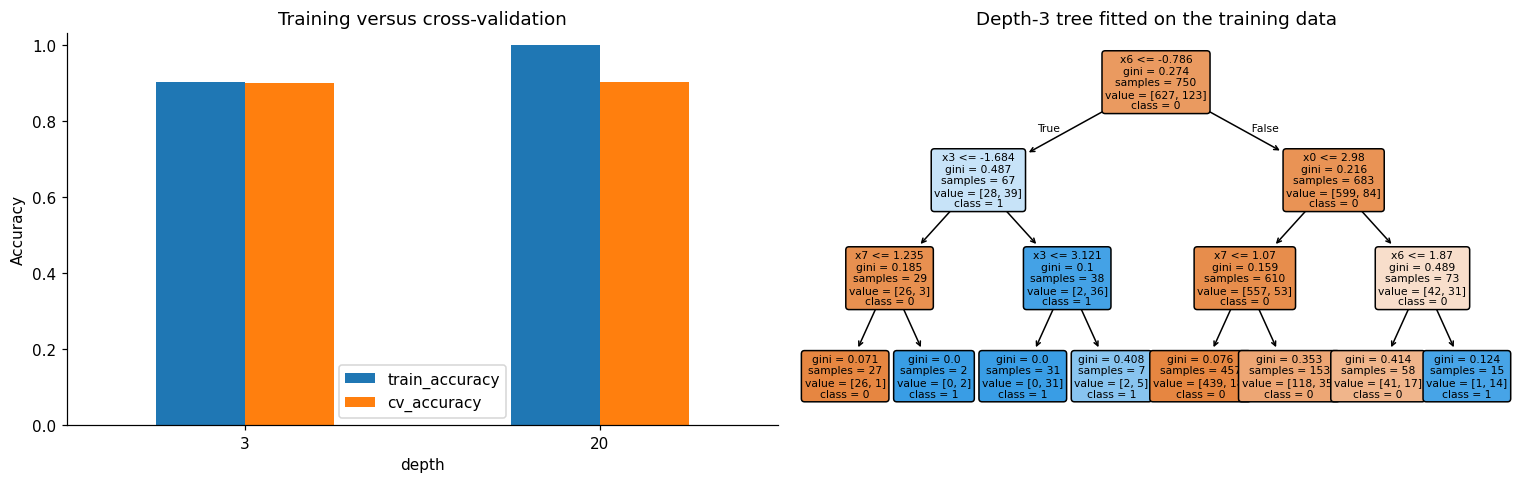

In [22]:
try:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
    depth_results[['train_accuracy', 'cv_accuracy']].plot.bar(ax=axes[0], rot=0)
    axes[0].set(ylabel='Accuracy', ylim=(0, 1.03), title='Training versus cross-validation')
    plot_tree(models_by_depth[3], feature_names=list(X_train.columns),
              class_names=['0', '1'], filled=True, rounded=True, fontsize=7, ax=axes[1])
    axes[1].set_title('Depth-3 tree fitted on the training data')
    plt.tight_layout()
    plt.show()
except Exception as exc:
    plt.close("all")
    print("Complete the preceding task to display this result:", type(exc).__name__ + ":", str(exc))


## Task 2.2 — Choose tree complexity with cross-validation

Fit `tree_search = GridSearchCV(...)` on `X_train, y_train` using:

- estimator: `DecisionTreeClassifier(random_state=RANDOM_STATE)`;
- `param_grid={'max_depth': [1, 2, 3, 5, None], 'min_samples_leaf': [1, 5]}`;
- `scoring='f1'`, `cv=CV`, `n_jobs=1`, `refit=True`.

`max_depth=None` removes the depth limit. `min_samples_leaf` sets the minimum
number of training rows per leaf. The selected tree is refitted on all training rows.


In [23]:
# Task 2.2: complete this answer cell, then run its check.
TASK_RUN_ERRORS.pop('2.2', None)
try:
    tree_search = GridSearchCV(
        DecisionTreeClassifier(random_state=RANDOM_STATE),
        param_grid={'max_depth': [1, 2, 3, 5, None], 'min_samples_leaf': [1, 5]},
        scoring='f1', cv=CV, n_jobs=1, refit=True,
    )
    tree_search.fit(X_train, y_train)
except Exception as exc:
    TASK_RUN_ERRORS['2.2'] = type(exc).__name__ + ": " + str(exc)
    print("Task 2.2 needs attention:", TASK_RUN_ERRORS['2.2'])

In [24]:
# Automatic check — provided code; do not edit.
def _check_2_2():
    check_training_data()
    def make_reference():
        return GridSearchCV(DecisionTreeClassifier(random_state=42),
            {'max_depth': [1, 2, 3, 5, None], 'min_samples_leaf': [1, 5]},
            scoring='f1', cv=StratifiedKFold(3, shuffle=True, random_state=42),
            n_jobs=1, refit=True).fit(X_train, y_train)
    expected = reference_result('tree_search', make_reference)
    same_search(tree_search, expected)

CHECKS['2.2'] = _check_2_2
run_check('2.2', 'Choose tree complexity with cross-validation')


✅ PASS  [2.2] Choose tree complexity with cross-validation


True

,param_max_depth,param_min_samples_leaf,mean_cv_f1,std_cv_f1
0,1,1,0.242077,0.178763
1,1,5,0.242077,0.178763
2,2,1,0.409228,0.092875
3,2,5,0.409228,0.092875
4,3,1,0.588242,0.060899
5,3,5,0.594723,0.079300
6,5,1,0.674510,0.040280
7,5,5,0.703247,0.007262
8,None,1,0.685185,0.026189
9,None,5,0.718800,0.014161


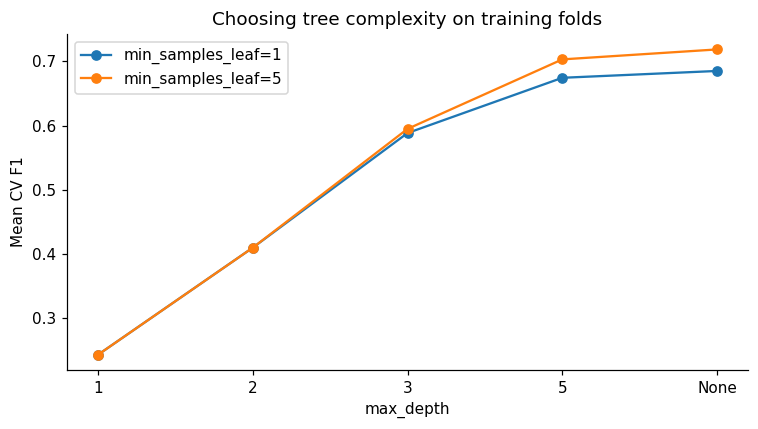

In [25]:
try:
    tree_cv_table = pd.DataFrame(tree_search.cv_results_)[
        ['param_max_depth', 'param_min_samples_leaf', 'mean_test_score', 'std_test_score']]
    display(tree_cv_table.rename(columns={'mean_test_score': 'mean_cv_f1',
                                          'std_test_score': 'std_cv_f1'}))
    fig, ax = plt.subplots(figsize=(7, 4))
    for leaf in (1, 5):
        subset = tree_cv_table[tree_cv_table['param_min_samples_leaf'] == leaf]
        ax.plot(range(5), subset['mean_test_score'], marker='o', label=f'min_samples_leaf={leaf}')
    ax.set(xticks=range(5), xticklabels=['1', '2', '3', '5', 'None'],
           xlabel='max_depth', ylabel='Mean CV F1', title='Choosing tree complexity on training folds')
    ax.legend()
    plt.tight_layout()
    plt.show()
except Exception as exc:
    plt.close("all")
    print("Complete the preceding task to display this result:", type(exc).__name__ + ":", str(exc))


# 3. Class weights

Run the provided metrics helper below for the final evaluation. Class **1** is
positive; a metric with a zero denominator returns 0.


In [26]:
# Provided metrics helper.
def metrics_binary(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    tp = int(np.sum((y_true == 1) & (y_pred == 1)))
    tn = int(np.sum((y_true == 0) & (y_pred == 0)))
    fp = int(np.sum((y_true == 0) & (y_pred == 1)))
    fn = int(np.sum((y_true == 1) & (y_pred == 0)))
    return dict(TP=tp, TN=tn, FP=fp, FN=fn,
                precision=tp / (tp + fp) if tp + fp else 0.0,
                recall=tp / (tp + fn) if tp + fn else 0.0,
                f1=2 * tp / (2 * tp + fp + fn) if 2 * tp + fp + fn else 0.0,
                accuracy=(tp + tn) / len(y_true) if len(y_true) else 0.0)


## Task 3.1 — Evaluate a class-weighted tree

Fit `weighted_tree = DecisionTreeClassifier(class_weight='balanced', random_state=RANDOM_STATE)`
on the training set. Compute `weighted_cv_scores`, the three F1 scores returned by
`cross_val_score(weighted_tree, X_train, y_train, scoring='f1', cv=CV, n_jobs=1)`.

Balanced weights give more weight to rarer classes: \(w_c=n/(K n_c)\), where
\(n\) is the number of training rows, \(K\) the number of classes and \(n_c\) the
count for class \(c\). Each CV fit computes these weights from its training fold.


In [27]:
# Task 3.1: complete this answer cell, then run its check.
TASK_RUN_ERRORS.pop('3.1', None)
try:
    weighted_tree = DecisionTreeClassifier(class_weight='balanced', random_state=RANDOM_STATE)
    weighted_tree.fit(X_train, y_train)

    weighted_cv_scores = cross_val_score(
        weighted_tree, X_train, y_train, scoring='f1', cv=CV, n_jobs=1,
    )
except Exception as exc:
    TASK_RUN_ERRORS['3.1'] = type(exc).__name__ + ": " + str(exc)
    print("Task 3.1 needs attention:", TASK_RUN_ERRORS['3.1'])

In [28]:
# Automatic check — provided code; do not edit.
def _check_3_1():
    check_training_data()
    def make_reference():
        model = DecisionTreeClassifier(class_weight='balanced', random_state=42)
        model.fit(X_train, y_train)
        scores = cross_val_score(model, X_train, y_train, scoring='f1',
            cv=StratifiedKFold(3, shuffle=True, random_state=42), n_jobs=1)
        return {'model': model, 'scores': scores}
    expected = reference_result('weighted_tree', make_reference)
    same_fitted_model(weighted_tree, expected['model'])
    require(np.asarray(weighted_cv_scores).shape == (3,), 'Store three CV F1 scores.')
    require(np.allclose(weighted_cv_scores, expected['scores'], atol=1e-10, rtol=0),
            'Compute F1 on held-out training folds, using the specified balanced estimator and CV.')

CHECKS['3.1'] = _check_3_1
run_check('3.1', 'Evaluate a class-weighted tree')


✅ PASS  [3.1] Evaluate a class-weighted tree


True

# 4. Bagging and random forests

A single deep tree can change substantially when the training data change.
Bagging fits several trees on **bootstrap samples**: for a training set of size
$n$, draw $n$ row indices **independently with replacement**. Some rows appear
several times; others are absent from that tree's training sample.

Combining diverse trees can reduce variance.

`BaggingClassifier` with decision trees averages the trees' predicted class
probabilities and selects the class with the largest average probability.
This can differ from majority voting on their class labels.

Use the same three training-data CV folds and F1 for class 1 throughout.


## Task 4.1 — Bootstrap sampling and bagging

1. Implement `bootstrap_indices(n, rng)`. For positive integer `n`, return a
   one-dimensional NumPy integer array of length `n`, sampled uniformly with
   replacement from `0, ..., n - 1`. Use the supplied NumPy `Generator` `rng`.
2. Create `bagging_model = BaggingClassifier(...)` using a default
   `DecisionTreeClassifier(random_state=RANDOM_STATE)` as its `estimator`,
   `n_estimators=40`, `bootstrap=True`, `random_state=RANDOM_STATE`, and
   `n_jobs=1`. Keep the other parameters at their defaults.
3. Fit `bagging_model` on `X_train, y_train`. Store its three CV F1 scores in
   `bagging_cv_scores` using `cross_val_score(..., cv=CV, scoring="f1")`.

`bootstrap_indices` demonstrates the sampling rule. Fit `BaggingClassifier`
on the full training set; it draws its own bootstrap samples.


In [29]:
# Task 4.1: complete this answer cell, then run its check.
TASK_RUN_ERRORS.pop('4.1', None)
try:
    def bootstrap_indices(n, rng):
        return rng.integers(0, n, size=n)

    bagging_model = BaggingClassifier(
        estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
        n_estimators=40, bootstrap=True, random_state=RANDOM_STATE, n_jobs=1,
    )
    bagging_model.fit(X_train, y_train)

    bagging_cv_scores = cross_val_score(
        bagging_model, X_train, y_train, cv=CV, scoring="f1",
    )
except Exception as exc:
    TASK_RUN_ERRORS['4.1'] = type(exc).__name__ + ": " + str(exc)
    print("Task 4.1 needs attention:", TASK_RUN_ERRORS['4.1'])

In [30]:
# Automatic check — provided code; do not edit.
def _check_4_1():
    check_training_data()
    require(callable(bootstrap_indices), "Define bootstrap_indices(n, rng).")
    for n, seed in [(1, 7), (7, 11), (32, 17), (64, 29)]:
        result = bootstrap_indices(n, np.random.default_rng(seed))
        repeated = bootstrap_indices(n, np.random.default_rng(seed))
        require(isinstance(result, np.ndarray), "bootstrap_indices must return a NumPy array.")
        require(result.shape == (n,), "A bootstrap sample must contain exactly n indices.")
        require(np.issubdtype(result.dtype, np.integer), "Bootstrap indices must be integers.")
        require(np.all((result >= 0) & (result < n)), "Each bootstrap index must be between 0 and n-1.")
        require(np.array_equal(result, repeated), "Use the supplied rng so sampling is reproducible.")
    rng = np.random.default_rng(9102)
    samples = [bootstrap_indices(50, rng) for _ in range(100)]
    require(all(isinstance(x, np.ndarray) and x.shape == (50,) for x in samples), "Return n indices on every call.")
    require(all(np.issubdtype(x.dtype, np.integer) and np.all((x >= 0) & (x < 50)) for x in samples), "Every repeated sample must contain valid integer indices.")
    require(any(np.unique(x).size < 50 for x in samples), "Bootstrap sampling must allow repeated rows; a permutation is not a bootstrap sample.")
    require(any(not np.array_equal(samples[0], x) for x in samples[1:]), "Advance the supplied generator; do not reset a fixed seed on each call.")
    counts = np.bincount(np.concatenate(samples), minlength=50)
    require(np.all((counts > 55) & (counts < 150)), "Rows should be sampled approximately uniformly, not from a restricted or biased subset.")
    unique_mean = np.mean([np.unique(x).size for x in samples])
    require(28 < unique_mean < 36, "Draw independently with replacement; do not force each row to occur once.")

    def expected_bagging():
        model = BaggingClassifier(
            estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
            n_estimators=40, bootstrap=True, random_state=RANDOM_STATE, n_jobs=1,
        )
        scores = cross_val_score(model, X_train, y_train, cv=CV, scoring="f1", n_jobs=1)
        model.fit(X_train, y_train)
        return {"model": model, "scores": scores}

    expected = reference_result("ensemble_bagging", expected_bagging)
    require(isinstance(bagging_model, BaggingClassifier), "Create bagging_model with BaggingClassifier.")
    same_fitted_model(bagging_model, expected["model"])
    require(np.asarray(bagging_cv_scores).shape == (3,), "Store one F1 score for each of the three CV folds.")
    require(np.allclose(np.asarray(bagging_cv_scores, dtype=float), expected["scores"]), "Recompute bagging_cv_scores on X_train/y_train using CV and scoring='f1'.")
    require(all(np.array_equal(a, e) for a, e in zip(bagging_model.estimators_samples_, expected["model"].estimators_samples_)), "Use the specified bootstrap samples through random_state=RANDOM_STATE.")

CHECKS['4.1'] = _check_4_1
run_check('4.1', 'Bootstrap sampling and bagging')


✅ PASS  [4.1] Bootstrap sampling and bagging


True

In [31]:
try:
    example_sample = bootstrap_indices(20, np.random.default_rng(RANDOM_STATE))
    print("Example bootstrap indices:", example_sample)
    print("Distinct rows in this sample:", np.unique(example_sample).size, "out of 20")
    print("Bagging CV F1: {:.3f} +/- {:.3f}".format(np.mean(bagging_cv_scores), np.std(bagging_cv_scores)))
except Exception as exc:
    plt.close("all")
    print("Complete the preceding task to display this result:", type(exc).__name__ + ":", str(exc))


Example bootstrap indices: [ 1 15 13  8  8 17  1 13  4  1 10 19 14 15 14 15 10  2 16  9]
Distinct rows in this sample: 12 out of 20
Bagging CV F1: 0.759 +/- 0.032


A **random forest** adds another source of diversity: each split considers a
random subset of candidate features. `max_features="sqrt"` uses approximately
the square root of the number of features at each split; `max_features=1.0`
makes all features available at each split.

With bootstrap sampling, each tree leaves out some training rows. An
**out-of-bag (OOB)** prediction for a row combines only trees whose bootstrap
sample omitted that row.

The default `oob_score_` is **accuracy**, while we select models by **CV F1**.
Label these scores separately: both their metrics and evaluation samples differ.


## Task 4.2 — Tune a random forest on training data

Create `rf_search` as a `GridSearchCV` for
`RandomForestClassifier(bootstrap=True, oob_score=True,
random_state=RANDOM_STATE, n_jobs=1)` with:

- `param_grid={"n_estimators": [30, 80], "max_features": ["sqrt", 1.0]}`;
- `scoring="f1"`, `cv=CV`, `n_jobs=1`, and the default `refit=True`.

Fit the search on `X_train, y_train`. Set `rf_oob_accuracy` to the selected
forest's `oob_score_`. All remaining forest parameters should use their defaults.
The selected forest is available as `rf_search.best_estimator_`.


In [32]:
# Task 4.2: complete this answer cell, then run its check.
TASK_RUN_ERRORS.pop('4.2', None)
try:
    rf_search = GridSearchCV(
        RandomForestClassifier(bootstrap=True, oob_score=True, random_state=RANDOM_STATE, n_jobs=1),
        param_grid={"n_estimators": [30, 80], "max_features": ["sqrt", 1.0]},
        scoring="f1", cv=CV, n_jobs=1,
    )
    rf_search.fit(X_train, y_train)

    rf_oob_accuracy = rf_search.best_estimator_.oob_score_
except Exception as exc:
    TASK_RUN_ERRORS['4.2'] = type(exc).__name__ + ": " + str(exc)
    print("Task 4.2 needs attention:", TASK_RUN_ERRORS['4.2'])

In [33]:
# Automatic check — provided code; do not edit.
def _check_4_2():
    check_training_data()

    def expected_rf():
        search = GridSearchCV(
            RandomForestClassifier(bootstrap=True, oob_score=True, random_state=RANDOM_STATE, n_jobs=1),
            param_grid={"n_estimators": [30, 80], "max_features": ["sqrt", 1.0]},
            scoring="f1", cv=CV, n_jobs=1,
        )
        return search.fit(X_train, y_train)

    expected = reference_result("ensemble_rf_search", expected_rf)
    require(isinstance(rf_search, GridSearchCV), "Create and fit rf_search using GridSearchCV.")
    same_search(rf_search, expected)
    require(isinstance(rf_search.best_estimator_, RandomForestClassifier), "The search must tune a random forest.")
    require(rf_oob_accuracy is not None and np.isscalar(rf_oob_accuracy), "Store the selected forest's OOB accuracy in rf_oob_accuracy.")
    require(np.isclose(float(rf_oob_accuracy), expected.best_estimator_.oob_score_), "rf_oob_accuracy must be the selected forest's oob_score_, not its CV F1 score.")
    require(np.allclose(rf_search.best_estimator_.oob_decision_function_, expected.best_estimator_.oob_decision_function_), "Fit the selected forest with bootstrap=True and oob_score=True on the training data.")

CHECKS['4.2'] = _check_4_2
run_check('4.2', 'Tune a random forest on training data')


✅ PASS  [4.2] Tune a random forest on training data


True

In [34]:
try:
    display(pd.DataFrame(rf_search.cv_results_)[["params", "mean_test_score", "std_test_score"]].rename(
        columns={"mean_test_score": "mean_cv_f1", "std_test_score": "std_cv_f1"}
    ))
    print("Selected parameters:", rf_search.best_params_)
    print("Selected mean CV F1: {:.3f}".format(rf_search.best_score_))
    print("Selected forest OOB accuracy: {:.3f}".format(rf_oob_accuracy))
except Exception as exc:
    plt.close("all")
    print("Complete the preceding task to display this result:", type(exc).__name__ + ":", str(exc))


,params,mean_cv_f1,std_cv_f1
0,"{'max_features': 'sqrt', 'n_estimators': 30}",0.702889,0.090143
1,"{'max_features': 'sqrt', 'n_estimators': 80}",0.725663,0.056932
2,"{'max_features': 1.0, 'n_estimators': 30}",0.747791,0.023599
3,"{'max_features': 1.0, 'n_estimators': 80}",0.756507,0.034545


Selected parameters: {'max_features': 1.0, 'n_estimators': 80}
Selected mean CV F1: 0.757
Selected forest OOB accuracy: 0.933


# 5. Boosting and a final model comparison

**Gradient boosting** adds trees sequentially, fitting each new tree to the
negative gradient of the current ensemble's loss. For squared-error regression,
this gradient is proportional to the residual.

`learning_rate` scales each new tree's contribution, and `n_estimators` controls
the number of stages. We tune both parameters for a `GradientBoostingClassifier`
with `max_depth=2`.


## Task 5.1 — Tune a gradient boosting classifier

Create and fit `boost_search` as a `GridSearchCV` for
`GradientBoostingClassifier(max_depth=2, random_state=RANDOM_STATE)` with:

- `param_grid={"n_estimators": [30, 80], "learning_rate": [0.05, 0.15]}`;
- `scoring="f1"`, `cv=CV`, `n_jobs=1`, and the default `refit=True`.

Fit on `X_train, y_train` and keep the remaining classifier parameters at their
defaults.


In [35]:
# Task 5.1: complete this answer cell, then run its check.
TASK_RUN_ERRORS.pop('5.1', None)
try:
    boost_search = GridSearchCV(
        GradientBoostingClassifier(max_depth=2, random_state=RANDOM_STATE),
        param_grid={"n_estimators": [30, 80], "learning_rate": [0.05, 0.15]},
        scoring="f1", cv=CV, n_jobs=1,
    )
    boost_search.fit(X_train, y_train)
except Exception as exc:
    TASK_RUN_ERRORS['5.1'] = type(exc).__name__ + ": " + str(exc)
    print("Task 5.1 needs attention:", TASK_RUN_ERRORS['5.1'])

In [36]:
# Automatic check — provided code; do not edit.
def _check_5_1():
    check_training_data()

    def expected_boost():
        search = GridSearchCV(
            GradientBoostingClassifier(max_depth=2, random_state=RANDOM_STATE),
            param_grid={"n_estimators": [30, 80], "learning_rate": [0.05, 0.15]},
            scoring="f1", cv=CV, n_jobs=1,
        )
        return search.fit(X_train, y_train)

    expected = reference_result("ensemble_boost_search", expected_boost)
    require(isinstance(boost_search, GridSearchCV), "Create and fit boost_search using GridSearchCV.")
    same_search(boost_search, expected)
    require(isinstance(boost_search.best_estimator_, GradientBoostingClassifier), "The search must tune GradientBoostingClassifier.")
    require(np.allclose(boost_search.best_estimator_.predict_proba(X_train), expected.best_estimator_.predict_proba(X_train)), "Fit the specified boosting model on the training data.")

CHECKS['5.1'] = _check_5_1
run_check('5.1', 'Tune a gradient boosting classifier')


✅ PASS  [5.1] Tune a gradient boosting classifier


True

In [37]:
try:
    display(pd.DataFrame(boost_search.cv_results_)[["params", "mean_test_score", "std_test_score"]].rename(
        columns={"mean_test_score": "mean_cv_f1", "std_test_score": "std_cv_f1"}
    ))
    print("Selected parameters:", boost_search.best_params_)
    print("Selected mean CV F1: {:.3f}".format(boost_search.best_score_))
except Exception as exc:
    plt.close("all")
    print("Complete the preceding task to display this result:", type(exc).__name__ + ":", str(exc))


,params,mean_cv_f1,std_cv_f1
0,"{'learning_rate': 0.05, 'n_estimators': 30}",0.546481,0.014796
1,"{'learning_rate': 0.05, 'n_estimators': 80}",0.617731,0.042961
2,"{'learning_rate': 0.15, 'n_estimators': 30}",0.625033,0.051129
3,"{'learning_rate': 0.15, 'n_estimators': 80}",0.676489,0.056201


Selected parameters: {'learning_rate': 0.15, 'n_estimators': 80}
Selected mean CV F1: 0.676


## Task 5.2 — Select by CV, then evaluate the selected model on the test set

Build `comparison_table`, a DataFrame with columns `family` and `cv_f1` and
these five rows **in this order**:

1. `"Decision tree"`: `tree_search.best_score_`;
2. `"Weighted tree"`: the mean of `weighted_cv_scores`;
3. `"Bagging"`: the mean of `bagging_cv_scores`;
4. `"Random forest"`: `rf_search.best_score_`;
5. `"Gradient boosting"`: `boost_search.best_score_`.

Set `selected_family` to the family with the largest `cv_f1`. If values tie,
choose the first tied row in the order above. Clone that family's estimator,
fit the clone on all of `X_train, y_train`, and store it as `final_model`.
Use the tuned searches' `best_estimator_`, `weighted_tree`, or `bagging_model`
as appropriate.

**Evaluate only the selected model on the test set.** Store
`final_model.predict(X_test)` as `test_pred`, and compute
`test_metrics = metrics_binary(y_test, test_pred)` using the provided helper.
Keep the selection fixed after seeing these results.

The winning CV score can be optimistic because it was used for selection.
The held-out test result provides a separate final assessment.


In [38]:
# Task 5.2: complete this answer cell, then run its check.
TASK_RUN_ERRORS.pop('5.2', None)
try:
    comparison_table = pd.DataFrame({
        "family": ["Decision tree", "Weighted tree", "Bagging", "Random forest", "Gradient boosting"],
        "cv_f1": [
            tree_search.best_score_,
            np.mean(weighted_cv_scores),
            np.mean(bagging_cv_scores),
            rf_search.best_score_,
            boost_search.best_score_,
        ],
    })

    selected_family = comparison_table.loc[comparison_table["cv_f1"].idxmax(), "family"]

    family_to_estimator = {
        "Decision tree": tree_search.best_estimator_,
        "Weighted tree": weighted_tree,
        "Bagging": bagging_model,
        "Random forest": rf_search.best_estimator_,
        "Gradient boosting": boost_search.best_estimator_,
    }

    final_model = clone(family_to_estimator[selected_family])
    final_model.fit(X_train, y_train)

    test_pred = final_model.predict(X_test)
    test_metrics = metrics_binary(y_test, test_pred)
except Exception as exc:
    TASK_RUN_ERRORS['5.2'] = type(exc).__name__ + ": " + str(exc)
    print("Task 5.2 needs attention:", TASK_RUN_ERRORS['5.2'])

In [39]:
# Automatic check — provided code; do not edit.
def _check_5_2():
    check_training_data()
    require(isinstance(comparison_table, pd.DataFrame), "Build comparison_table as a pandas DataFrame.")
    require(list(comparison_table.columns) == ["family", "cv_f1"], "Use comparison_table columns family and cv_f1.")
    names = ["Decision tree", "Weighted tree", "Bagging", "Random forest", "Gradient boosting"]
    require(comparison_table["family"].tolist() == names, "Include the five model families in the required order.")
    # Earlier checks build independent references. If a preceding answer failed
    # before its reference was built, construct that reference here as well.
    def expected_tree():
        return GridSearchCV(
            DecisionTreeClassifier(random_state=RANDOM_STATE),
            param_grid={"max_depth": [1, 2, 3, 5, None], "min_samples_leaf": [1, 5]},
            scoring="f1", cv=CV, n_jobs=1,
        ).fit(X_train, y_train)
    def expected_weighted():
        model = DecisionTreeClassifier(class_weight="balanced", random_state=RANDOM_STATE)
        scores = cross_val_score(model, X_train, y_train, cv=CV, scoring="f1", n_jobs=1)
        model.fit(X_train, y_train)
        return {"model": model, "scores": scores}
    def expected_bagging():
        model = BaggingClassifier(
            estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
            n_estimators=40, bootstrap=True, random_state=RANDOM_STATE, n_jobs=1,
        )
        scores = cross_val_score(model, X_train, y_train, cv=CV, scoring="f1", n_jobs=1)
        model.fit(X_train, y_train)
        return {"model": model, "scores": scores}
    def expected_rf():
        return GridSearchCV(
            RandomForestClassifier(bootstrap=True, oob_score=True, random_state=RANDOM_STATE, n_jobs=1),
            param_grid={"n_estimators": [30, 80], "max_features": ["sqrt", 1.0]},
            scoring="f1", cv=CV, n_jobs=1,
        ).fit(X_train, y_train)
    def expected_boost():
        return GridSearchCV(
            GradientBoostingClassifier(max_depth=2, random_state=RANDOM_STATE),
            param_grid={"n_estimators": [30, 80], "learning_rate": [0.05, 0.15]},
            scoring="f1", cv=CV, n_jobs=1,
        ).fit(X_train, y_train)
    refs = [
        reference_result("tree_search", expected_tree),
        reference_result("weighted_tree", expected_weighted),
        reference_result("ensemble_bagging", expected_bagging),
        reference_result("ensemble_rf_search", expected_rf),
        reference_result("ensemble_boost_search", expected_boost),
    ]
    scores = np.array([refs[0].best_score_, np.mean(refs[1]["scores"]), np.mean(refs[2]["scores"]), refs[3].best_score_, refs[4].best_score_])
    require(np.allclose(comparison_table["cv_f1"].to_numpy(dtype=float), scores), "Each table entry must contain the corresponding mean training-data CV F1.")
    chosen = int(np.argmax(scores))
    require(selected_family == names[chosen], "Select the largest mean CV F1; break ties by the first table row.")
    expected_models = [refs[0].best_estimator_, refs[1]["model"], refs[2]["model"], refs[3].best_estimator_, refs[4].best_estimator_]
    expected_model = expected_models[chosen]
    same_fitted_model(final_model, expected_model)
    expected_pred = expected_model.predict(X_test)
    require(np.asarray(test_pred).shape == y_test.shape, "Store one test prediction per test row.")
    require(np.array_equal(test_pred, expected_pred), "test_pred must come from the selected model fitted on all training rows.")
    require(np.array_equal(final_model.predict(X_test), expected_pred), "final_model must reproduce the selected model's test predictions.")
    truth = np.asarray(y_test)
    tp = int(np.sum((truth == 1) & (expected_pred == 1)))
    tn = int(np.sum((truth == 0) & (expected_pred == 0)))
    fp = int(np.sum((truth == 0) & (expected_pred == 1)))
    fn = int(np.sum((truth == 1) & (expected_pred == 0)))
    expected_metrics = {
        "TP": tp, "TN": tn, "FP": fp, "FN": fn,
        "precision": tp / (tp + fp) if tp + fp else 0.0,
        "recall": tp / (tp + fn) if tp + fn else 0.0,
        "f1": 2 * tp / (2 * tp + fp + fn) if 2 * tp + fp + fn else 0.0,
        "accuracy": (tp + tn) / len(truth),
    }
    require(isinstance(test_metrics, dict), "Compute test_metrics with metrics_binary(y_test, test_pred).")
    require(set(expected_metrics).issubset(test_metrics), "test_metrics must include TP, TN, FP, FN, precision, recall, f1, accuracy.")
    for key, value in expected_metrics.items():
        require(np.isscalar(test_metrics[key]) and np.isclose(float(test_metrics[key]), value), "Incorrect test metric: " + key)

CHECKS['5.2'] = _check_5_2
run_check('5.2', 'Select by CV, then evaluate the selected model on the test set')


✅ PASS  [5.2] Select by CV, then evaluate the selected model on the test set


True

,family,cv_f1
0,Decision tree,0.718800
1,Weighted tree,0.651788
2,Bagging,0.758665
3,Random forest,0.756507
4,Gradient boosting,0.676489


Selected family: Bagging


,TP,TN,FP,FN,precision,recall,f1,accuracy
held-out test,31,205,4,10,0.885714,0.756098,0.815789,0.944


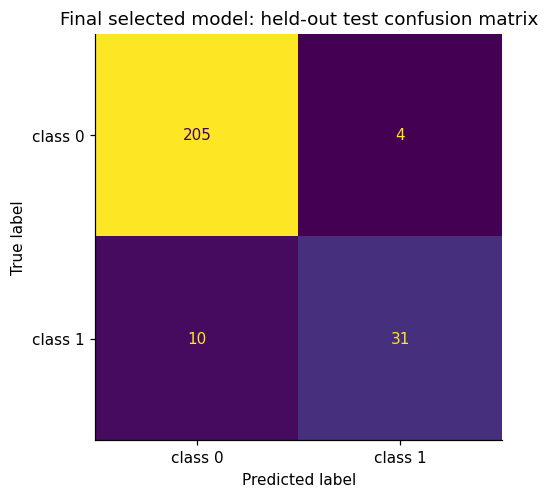

In [40]:
try:
    display(comparison_table)
    print("Selected family:", selected_family)
    display(pd.DataFrame([test_metrics], index=["held-out test"]))
    ConfusionMatrixDisplay.from_predictions(y_test, test_pred, display_labels=["class 0", "class 1"], colorbar=False)
    plt.title("Final selected model: held-out test confusion matrix")
    plt.show()
except Exception as exc:
    plt.close("all")
    print("Complete the preceding task to display this result:", type(exc).__name__ + ":", str(exc))


## Task 5.3 — Check the main ideas

Fill `concept_answers` with the keys `q1` to `q5` and the correct option
(`"a"`, `"b"`, or `"c"`) for each question.

**q1. What usually changes when a tree's permitted depth increases?**

- a. Its training accuracy must decrease.
- b. Its capacity increases, while validation performance need not improve.
- c. Both its training and validation performance must improve.

**q2. Which procedure generates a bootstrap sample of size n?**

- a. Draw n row indices independently and uniformly with replacement.
- b. Randomly permute the n rows, using each exactly once.
- c. Keep the n rows with the largest prediction errors.

**q3. How does a random forest use `max_features`?**

- a. It permanently removes the least useful columns before fitting.
- b. It chooses one fixed subset of columns for the entire forest.
- c. It controls the number of candidate features considered at each split.

**q4. How are trees added in gradient boosting?**

- a. Sequentially, using the current loss's negative gradient to improve the ensemble.
- b. Independently, and the learning rate selects the bootstrap sample size.
- c. Sequentially, by fitting each tree to the test labels.

**q5. Which model-selection procedure is appropriate here?**

- a. Select the family with the highest test F1, then report that test F1.
- b. Adjust hyperparameters until the test confusion matrix looks best.
- c. Select parameters and family using training-data CV, then evaluate the selected model on the held-out test set.


In [41]:
# Task 5.3: complete this answer cell, then run its check.
TASK_RUN_ERRORS.pop('5.3', None)
try:
    concept_answers = {
        "q1": "b",
        "q2": "a",
        "q3": "c",
        "q4": "a",
        "q5": "c",
    }
except Exception as exc:
    TASK_RUN_ERRORS['5.3'] = type(exc).__name__ + ": " + str(exc)
    print("Task 5.3 needs attention:", TASK_RUN_ERRORS['5.3'])

In [42]:
# Automatic check — provided code; do not edit.
def _check_5_3():
    require(isinstance(concept_answers, dict), "Fill concept_answers with answers q1 to q5.")
    expected = {"q1": chr(98), "q2": chr(97), "q3": chr(99), "q4":  chr(97), "q5": chr(99)}
    missing = [key for key in expected if concept_answers.get(key) not in {"a", "b", "c"}]
    require(not missing, "Answer every required question using a, b, or c: " + ", ".join(missing))
    wrong = [key for key, value in expected.items() if concept_answers[key] != value]
    require(not wrong, "Revisit the explanation for: " + ", ".join(wrong))

CHECKS['5.3'] = _check_5_3
run_check('5.3', 'Check the main ideas')

✅ PASS  [5.3] Check the main ideas


True

# 6. Submission check

Use **Kernel → Restart Kernel and Run All Cells** before submitting.
The final check reruns all 11 tasks. **PASS requires at least 9 out of 11**
(80% rounded up to a whole task). Each numbered task counts equally;
the five questions in Task 5.3 together count as one task.

Submit the executed **student notebook**, including its outputs. Keep the
provided data, setup and checks intact, and submit your own implementations.


In [43]:
# Final automatic check — provided code; do not edit.
TASKS = [('1.1', 'Measure node impurity'), ('1.2', 'Compare candidate splits and choose the root'), ('1.3', 'Choose splits within each branch'), ('2.1', 'Shallow and deep trees'), ('2.2', 'Choose tree complexity with cross-validation'), ('3.1', 'Evaluate a class-weighted tree'), ('4.1', 'Bootstrap sampling and bagging'), ('4.2', 'Tune a random forest on training data'), ('5.1', 'Tune a gradient boosting classifier'), ('5.2', 'Select by CV, then evaluate the selected model on the test set'), ('5.3', 'Check the main ideas')]
PASS_PERCENT = 80
MIN_TASKS_TO_PASS = (PASS_PERCENT * len(TASKS) + 99) // 100
print('=' * 72)
print(f'SUBMISSION CHECK — at least {PASS_PERCENT}% ({MIN_TASKS_TO_PASS}/{len(TASKS)} tasks) to pass')
print('=' * 72)
FINAL_RESULTS = {}
for task_id, title in TASKS:
    FINAL_RESULTS[task_id] = run_check(task_id, title)
print('-' * 72)
passed_count = sum(FINAL_RESULTS.values())
SUBMISSION_PASS = passed_count >= MIN_TASKS_TO_PASS
print(f'{passed_count} / {len(TASKS)} tasks passed ({100 * passed_count / len(TASKS):.1f}%)')
print('RESULT: ' + ('PASS' if SUBMISSION_PASS else 'FAIL'))
if not SUBMISSION_PASS:
    print(f'Complete {MIN_TASKS_TO_PASS - passed_count} more task(s), then restart the kernel and run all cells.')


SUBMISSION CHECK — at least 80% (9/11 tasks) to pass
✅ PASS  [1.1] Measure node impurity
✅ PASS  [1.2] Compare candidate splits and choose the root
✅ PASS  [1.3] Choose splits within each branch
✅ PASS  [2.1] Shallow and deep trees
✅ PASS  [2.2] Choose tree complexity with cross-validation
✅ PASS  [3.1] Evaluate a class-weighted tree
✅ PASS  [4.1] Bootstrap sampling and bagging
✅ PASS  [4.2] Tune a random forest on training data
✅ PASS  [5.1] Tune a gradient boosting classifier
✅ PASS  [5.2] Select by CV, then evaluate the selected model on the test set
✅ PASS  [5.3] Check the main ideas
------------------------------------------------------------------------
11 / 11 tasks passed (100.0%)
RESULT: PASS
